In [1]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)
qc.qubits

[<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>]

In [3]:
print(type(qc.qubits[0]))

<class 'qiskit.circuit.Qubit'>


In [4]:
from qiskit.circuit import QuantumRegister, ClassicalRegister

qr1 = QuantumRegister(2, "qreg1")  # Create a QuantumRegister with 2 qubits
qr2 = QuantumRegister(1, "qreg2")  # Create a QuantumRegister with 1 qubit
cr1 = ClassicalRegister(3, "creg1")  # Create a ClassicalRegister with 3 cbits

combined_circ = QuantumCircuit(
    qr1, qr2, cr1
)  # Create a quantum circuit with 2 QuantumRegisters and 1 ClassicalRegister
combined_circ.qubits

[<Qubit register=(2, "qreg1"), index=0>,
 <Qubit register=(2, "qreg1"), index=1>,
 <Qubit register=(1, "qreg2"), index=0>]

You can find a qubit's index and register by using the circuit's find_bit method and its attributes.

In [5]:
desired_qubit = qr2[0]  # Qubit 0 of register 'qreg2'

print("Index:", combined_circ.find_bit(desired_qubit).index)
print("Register:", combined_circ.find_bit(desired_qubit).registers)

Index: 2
Register: [(QuantumRegister(1, 'qreg2'), 0)]


Adding an instruction to the circuit appends the instruction to the circuit's **data** attribute. The following cell output shows data is a list of CircuitInstruction objects, each of which has an operation attribute, and a qubits attribute.

In [8]:
qc.x(0)  # Add X-gate to qubit 0
qc.h(0)
qc.h(1)
qc.data
type(qc.data)


qiskit.circuit.quantumcircuitdata.QuantumCircuitData

In [13]:
print(type(qc.data[0].qubits))
print(qc.data[0].qubits[0])
print(type(qc.data[0].qubits[0]))

# FOR EXTRACTING THE INDEX!!!
print(qc.data[0].qubits[0]._index)

print(qc.data[0].operation.name)
print(qc.data)

<class 'tuple'>
<Qubit register=(2, "q"), index=0>
<class 'qiskit.circuit.Qubit'>
0
x
[CircuitInstruction(operation=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=()), CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=1>,), clbits=()), CircuitInstruction(operation=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=()), CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=1>,), clbits=()), CircuitInstruction(operation=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=()), CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=1>,), clbits=()), CircuitInstruction(

Circuit **Instruction** objects can contain "definition" circuits that describe the instruction in terms of more fundamental instructions. For example, the X-gate is defined as a specific case of the U3-gate, a more general single-qubit gate.

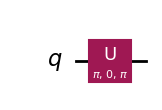

In [8]:
# Draw definition circuit of 0th instruction in `qc`
qc.data[0].operation.definition.draw("mpl")

## Build Circuits

Methods such as QuantumCircuit.h and QuantumCircuit.cx add specific instructions to circuits. To add instructions to a circuit more generally, use the append method. This takes an instruction and a list of qubits to apply the instruction to. See the Circuit Library API documentation for a list of supported instructions.

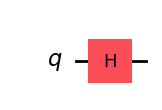

In [9]:
from qiskit.circuit.library import HGate

qc = QuantumCircuit(1)
qc.append(
    HGate(),  # New HGate instruction
    [0],  # Apply to qubit 0
)
qc.draw("mpl")

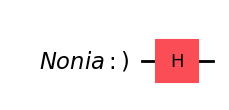

In [10]:
from qiskit.circuit.library import HGate
from qiskit import QuantumRegister
qreg = QuantumRegister(1, 'Nonia:)')
qc = QuantumCircuit(qreg)
qc.append(
    HGate(),  # New HGate instruction
    [0],  # Apply to qubit 0
)
qc.draw("mpl")

To combine two circuits, use the compose method. This accepts another QuantumCircuit and an optional list of qubit mappings.



The compose method returns a new circuit and does not mutate either circuit it acts on. To mutate the circuit on which you're calling the compose method, use the argument inplace=True.

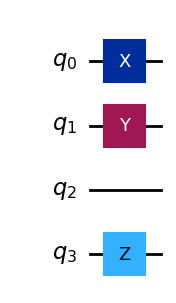

In [22]:
qc_a = QuantumCircuit(4)
qc_a.x(0)

qc_b = QuantumCircuit(2, name="qc_b")
qc_b.y(0)
qc_b.z(1)

# compose qubits (0, 1) of qc_a to qubits (1, 3) of qc_b respectively
combined = qc_a.compose(qc_b, qubits=[1, 3])
combined.draw("mpl")

You might also want to compile circuits into instructions to keep your circuits organized. You can convert a circuit to an instruction by using the to_instruction method, then append this to another circuit as you would any other instruction. The circuit drawn in the following cell is functionally equivalent to the circuit drawn in the previous cell.

<class 'qiskit.circuit.instruction.Instruction'>
<class 'qiskit._accelerate.circuit.CircuitInstruction'>


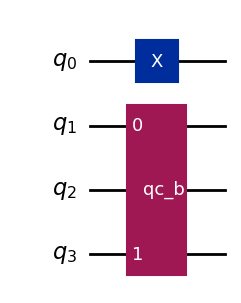

In [23]:
inst = qc_b.to_instruction()
print(type(inst))
print(type(qc_b.data[0]))
qc_a.append(inst, [1, 3])
qc_a.draw("mpl")

In [24]:
inst = qc_a.to_instruction()
qc_b.append(inst, [1, 3])
qc_b.draw("mpl")

CircuitError: 'Index 3 out of range for size 2.'

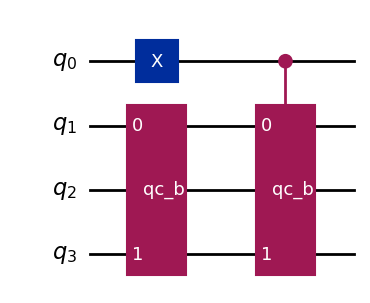

In [13]:
gate = qc_b.to_gate().control()
qc_a.append(gate, [0, 1, 3])
qc_a.draw("mpl")

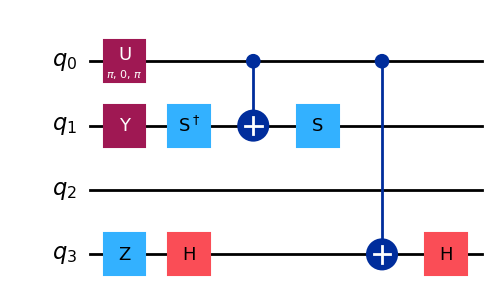

In [14]:
qc_a.decompose().draw("mpl")

## Measure qubits

Note that if you are submitting circuits to a Sampler primitive, measurements are required. However, circuits submitted to an Estimator primitive must not contain measurements.

Qubits can be measured using three methods: measure, measure_all and measure_active.

**QuantumCircuit.measure** : measures each qubit in the first argument onto the classical bit given as the second argument. This method allows full control over where the measurement result is stored.

**QuantumCircuit.measure_all** : takes no argument and can be used for quantum circuits without pre-defined classical bits. It creates classical wires and stores measurement results in order. For example, measurement of qubit q_{i} is stored in cbit meas_{i}). It also adds a barrier before the measurement.

**QuantumCircuit.measure_active** : similar to measure_all, but measures only qubits that have operations.

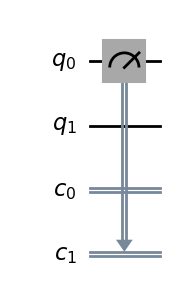

In [15]:
qc1 = QuantumCircuit(2, 2)
qc1.measure(0, 1)
qc1.draw("mpl", cregbundle=False)

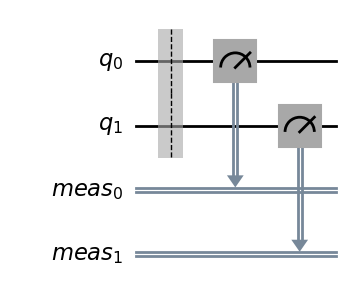

In [16]:
qc2 = QuantumCircuit(2)
qc2.measure_all()
qc2.draw("mpl", cregbundle=False)

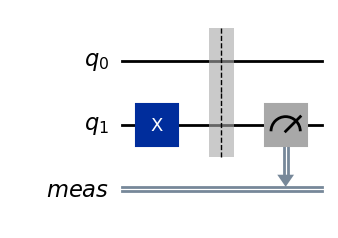

In [17]:
qc3 = QuantumCircuit(2)
qc3.x(1)
qc3.measure_active()
qc3.draw("mpl", cregbundle=False)

## Parametrized circuits

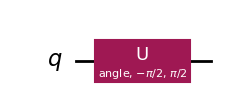

In [18]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.circuit import Parameter

angle = Parameter("angle")  # undefined number

# Create and optimize circuit once
qc = QuantumCircuit(1)
qc.rx(angle, 0)
qc = generate_preset_pass_manager(
    optimization_level=3, basis_gates=["u", "cx"]
).run(qc)

qc.draw("mpl")

{Parameter(angle): 0}
{Parameter(angle): 1}
{Parameter(angle): 2}
{Parameter(angle): 3}
{Parameter(angle): 4}
{Parameter(angle): 5}
{Parameter(angle): 6}
{Parameter(angle): 7}
{Parameter(angle): 8}
{Parameter(angle): 9}
{Parameter(angle): 10}
{Parameter(angle): 11}
{Parameter(angle): 12}
{Parameter(angle): 13}
{Parameter(angle): 14}
{Parameter(angle): 15}
{Parameter(angle): 16}
{Parameter(angle): 17}
{Parameter(angle): 18}
{Parameter(angle): 19}
{Parameter(angle): 20}
{Parameter(angle): 21}
{Parameter(angle): 22}
{Parameter(angle): 23}
{Parameter(angle): 24}
{Parameter(angle): 25}
{Parameter(angle): 26}
{Parameter(angle): 27}
{Parameter(angle): 28}
{Parameter(angle): 29}
{Parameter(angle): 30}
{Parameter(angle): 31}
{Parameter(angle): 32}
{Parameter(angle): 33}
{Parameter(angle): 34}
{Parameter(angle): 35}
{Parameter(angle): 36}
{Parameter(angle): 37}
{Parameter(angle): 38}
{Parameter(angle): 39}
{Parameter(angle): 40}
{Parameter(angle): 41}
{Parameter(angle): 42}
{Parameter(angle): 43

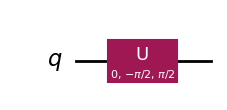

In [21]:
circuits = []
for value in range(100): #makes 100 circs with angles 0 to 99
    circuits.append(qc.assign_parameters({angle: value}))
    print({angle: value})
circuits[0].draw("mpl")

In [20]:
qc.parameters

ParameterView([Parameter(angle)])

### Change a parameter's name

By default, parameter names for a parameterized circuit are prefixed by x- for example, x[0]. You can change the names after they are defined, as shown in the following example.


In [22]:
from qiskit.circuit.library import z_feature_map
from qiskit.circuit import ParameterVector

# Define a parameterized circuit with default names
# For example, x[0]
circuit = z_feature_map(2)

# Set new parameter names
# They will now be prefixed by `hi` instead
# For example, hi[0]
training_params = ParameterVector("hi", 2)

# Assign parameter names to the quantum circuit
circuit = circuit.assign_parameters(parameters=training_params)

In [23]:
circuit.parameters

ParameterView([ParameterVectorElement(hi[0]), ParameterVectorElement(hi[1])])

ParameterView([Parameter(Nonia)])


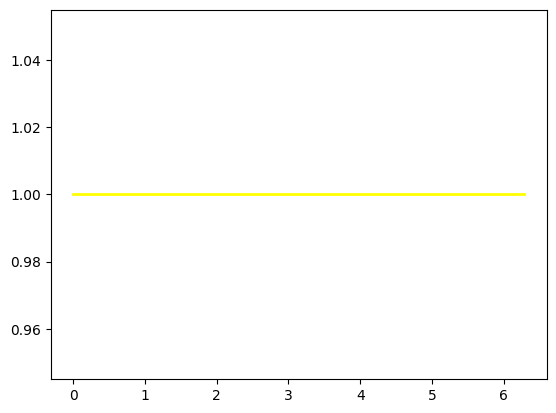

In [15]:
import numpy as np
from qiskit.circuit import Parameter
from qiskit_aer.primitives import EstimatorV2
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
import matplotlib.pylab as plt

angles = np.linspace(0, 2*np.pi, num=10)
param = Parameter('Nonia')

qc = QuantumCircuit(1)
qc.rz(param, 0)
expected_values = []
for angle in angles:
    observables = [SparsePauliOp('Z')]
    estimator = EstimatorV2()
    job = estimator.run([(qc.assign_parameters({param: angle}), observables)])
    expected_values.append(job.result()[0].data.evs)

plt.plot(angles, expected_values, color='Yellow', linewidth=2)
print(qc.parameters)

ParameterView([ParameterVectorElement(Nonia[0]), ParameterVectorElement(Nonia[1])])


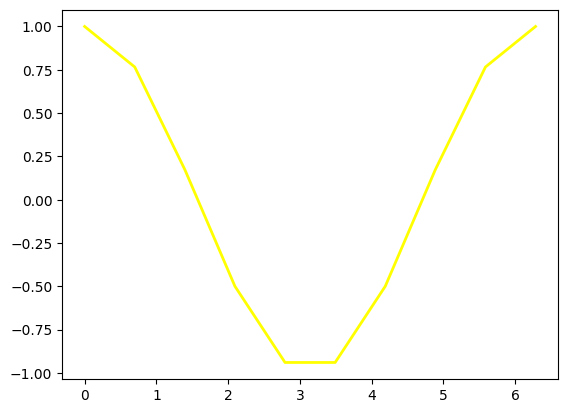

In [23]:
import numpy as np
from qiskit.circuit import ParameterVector
from qiskit_aer.primitives import EstimatorV2
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
import matplotlib.pylab as plt

angles = np.linspace(0, 2*np.pi, num=10)
params = ParameterVector('Nonia', 2)

qc = QuantumCircuit(1)
qc.rz(params[0], 0)
qc.rx(params[1], 0)

expected_values = []
for i in range(len(angles)):
    observables = [SparsePauliOp('Z')]
    estimator = EstimatorV2()
    parameter_values = [angles[i], angles[len(angles) - i-1]]
    #job = estimator.run([(qc, observables, parameter_values)])
    job = estimator.run([(qc.assign_parameters(parameter_values), observables)])
    expected_values.append(job.result()[0].data.evs)

plt.plot(angles, expected_values, color='Yellow', linewidth=2)
print(qc.parameters)